# Semi-Supervised Learning (SSL)


SSL studies how to learn from both labeled and unlabeled data, which can be useful when data is abundant but the resources to label them are limited.

In this exercise, you will:

* Given a simulated dataset with both labeled and unlabeled data, build a similarity graph and use the Harmonic Function Solution (HSF) to predict the labels of the unlabeled data;
* Use HSF for face recognition, given a fixed dataset;
* Implement an online version of HSF to label images as they appear in real time.

## 1. Harmonic Function Solution

Let $G = (V, E)$ be a weighted undirected graph where $V = \{x_1, \ldots, x_n \}$ is the vertex set and $E$ is the edge set. Each edge $e_{ij} \in E$ has a weight $w_{ij}$ and, if there is no edge between $x_i$ and $x_j$, then $w_{ij}=0$.

Let $|V| = n$ be the total number of nodes. Only a subset of the nodes $S \subset V$ with cardinality $|S| = l$ is labeled, and the remaining $u = n - l$ nodes are placed in the subset $T = V \setminus S$. 

Our goal is to predict the labels of the vertices in $T$ using the structure of the graph. Since we believe that nodes close in the graph should have similar labels, we would like to have each node surrounded by a majority of nodes with the same label. In order to do so, we impose that the labeling vector $f \in \mathbb{R}^n$ must be an **harmonic function** on the graph, that is:

$$
f_i = \frac{\sum_{j} w_{ij} f_j}{\sum_{j} w_{ij}},  \forall i \in T
$$

One interpretation for this constraint is that $w_{ij}$ represents the tendency of moving from node $x_i$ to node $x_j$, the stationary distribution of the transition matrix $P(j|i) = \tfrac{w_{ij}}{\sum_{k} w_{ik}}$  is a valid solution to our problem. 

### Hard HFS

It can be shown that $f$ is harmonic if and only if $(Lf)_T = 0$, where $(Lf)_T$ is the vector containing the values of $Lf$ for the nodes in the set $T$, and $L$ is the graph Laplacian. 

Hence, the harmonic function solution to the SSL problem is the solution to the following optimization problem:

$$
\min_{f \in \mathbb{R}^n}  f^T L f  
\quad \text{s.t} \quad
y_i = f(x_i) \quad \forall x_i \in S
$$
where $y_i$ are the labels available for the vertices $x_i \in S$. This gives us:

$$
f_T = L_{TT}^{-1}(W_{TS}f_S) = - L_{TT}^{-1}(L_{TS}f_S) 
$$

### Soft HFS

If the labels are noisy, we might need to replace the "hard" constraint of the optimization problem above by a "soft" constraint. Let $C$ be a diagonal matrix such that $C_{ii} = c_l$ for labeled examples and $C_{ii} = c_u$ otherwise. Also, define $y_i = 0$ for unlabeled examples, that is, for $x_i \in T$. 

The soft HFS objective function is

$$
\min_{f\in\mathbb{R}^n} (f-y)^T C (f-y) + f^T L f
$$
whose solution is 

$$
f^* = (C^{-1}L+I)^{-1}y
$$


### Implementation

Implement hard and soft HFS in the function `compute_hfs`. Complete the function `two_moons_hfs` to test your implementation using the datasets `data_2moons_hfs.mat` and `data_2moons_hfs_large.mat`.


* Tips: 
    * Don't forget to choose well the parameters to build the graph and its Laplacian.
    * You can use the functions `build_laplacian_regularized` and `build_similarity_graph`. The function `mask_labels` is used to chose how many labels are revealed.
    * Be careful: the labels are revealed randomly, and each random realization can have different results! Check how the `seed` parameter works.
    * Introduce noisy labels to compare hard and soft HFS.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.spatial.distance as sd
from scipy.io import loadmat
import os
from helper import build_similarity_graph, label_noise
from helper import build_laplacian, build_laplacian_regularized
from helper import plot_classification
from helper import mask_labels

In [4]:
import pandas as pd

In [5]:
"""
Define parameters for HFS
"""
params = {}

# regularization parameter (gamma)
params['laplacian_regularization'] = 1e-6

# the sigma value for the exponential (similarity) function, already squared
params['var'] = 1.0

# Threshold eps for epsilon graphs
params['eps'] = 0

# Number of neighbours k for k-nn. If zero, use epsilon-graph
params['k'] = 10

# String selecting which version of the laplacian matrix to construct.
# 'unn':  unnormalized, 'sym': symmetric normalization, 'rw':  random-walk normalization 
params['laplacian_normalization'] = 'unn'

# Coefficients for C matrix for soft HFS
params['c_l'] = 1000
params['c_u'] = 0.01

In [6]:
def compute_hfs(L, Y, soft=False,**params):
    """
    TO BE COMPLETED

    Function to perform HFS (hard or soft!).

    Parameters
    ----------
    L : array
        Graph Laplacian, (n x n) matrix (regularized or not)
    Y : array
        (n, ) array with nodes labels [0, 1, ... , num_classes] (0 is unlabeled)
    soft : bool
        If True, compute soft HFS. Otherwise, compute hard HFS.

    Returns
    --------
        Labels, class assignments for each of the n nodes
    """

    num_samples = L.shape[0]
    Cl = np.unique(Y)
    num_classes = len(Cl)-1

    """
    Build the vectors:
    y = (n x num_classes) target vector 
    l_idx = shape (l,) vector with indices of labeled nodes
    u_idx = shape (u,) vector with indices of unlabeled nodes
    """
    # ...

    y = np.zeros((num_samples,num_classes))
    for i in range(num_classes):
        y[Y == (i+1),i] = 1

    l_idx = np.where(Y > 0)[0]
    u_idx = np.where(Y == 0)[0]
    f = np.zeros((num_samples, num_classes))

    
    if not soft:    
        """
        Compute hard HFS.  

        f_l = solution for labeled data. 
        f_u = solution for unlabeled data
        f   = solution for all data
        """
       
        # ...
         
        L_uu = L[np.ix_(u_idx, u_idx)]
        L_ul = L[np.ix_(u_idx, l_idx)]

        for i in range(num_classes):

            f_l = y[l_idx,i]
            f_u = - np.linalg.inv(L_uu + params['laplacian_regularization']*np.identity(len(u_idx))) @ L_ul @ f_l 
            f[l_idx,i] = f_l
            f[u_idx,i] = f_u

    else:
        """
        Compute soft HFS.
        f = harmonic function solution 
        C = (n x n) diagonal matrix with c_l for labeled samples and c_u otherwise    
        """
        f = None
        C = None
        # ...
        c_diag = np.ones(num_samples)*params['c_u']
        c_diag[l_idx] = params['c_l']
        C = np.diag(c_diag)

        f = np.linalg.inv(np.identity(num_samples) + np.linalg.inv(C)@L)@y

        


    """
    return the labels assignment from the hfs solution, and the solution f
    labels: (n x 1) class assignments [1,2,...,num_classes]    
    f : harmonic function solution
    """
    labels = np.argmax(f, axis=1) + 1

    return labels, f


In [7]:
def two_moons_hfs(l=4, l_noisy=1, soft=False, dataset='data_2moons_hfs_large.mat', plot=True, seed=None,**params):
    """    
    TO BE COMPLETED.

    HFS for two_moons data.
    
    Parameters
    ----------
    l : int
        Number of labeled (unmasked) nodes provided to the HFS algorithm.
    l_noisy : int
        Number of *noisy* labels to introduce.
    soft : bool
        If true, use soft HFS, otherwise use hard HFS
    dataset : {'data_2moons_hfs.mat' or 'data_2moons_hfs_large.mat'}
        Which dataset to use.
    plot : bool
        If True, show plots
    seed : int
        If not None, set global numpy seed before choosing labels to reveal.
    """
    if seed is not None:
        np.random.seed(seed)

    # Load the data. At home, try to use the larger dataset.    
    in_data = loadmat(os.path.join('data', dataset))
    X = in_data['X']
    Y = np.array(in_data['Y'].squeeze(), dtype=np.uint32)

    # infer number of labels from samples
    num_samples = np.size(Y, 0)
    unique_classes = np.unique(Y)
    num_classes = len(unique_classes)
    
    # mask labels
    Y_masked = mask_labels(Y, l)
    assert len(np.unique(Y_masked)) > 2, "only one class in training data!"
    # introduce noise
    noise_indices = np.where(Y_masked == 0)[0]
    np.random.shuffle(noise_indices)
    noise_indices = noise_indices[:l_noisy]
    Y_masked[noise_indices] = np.random.choice(unique_classes, l_noisy)
  
    """
    compute hfs solution using either soft_hfs or hard_hfs
    """
    # Build graph Laplacian using the parameters:
    # params['laplacian_regularization'], params['var'], params['eps'], 
    # params['k'] and params['laplacian_normalization'].
    
    L = build_laplacian_regularized(
        X, 
        laplacian_regularization=params['laplacian_regularization'],
        var=params['var'],
        eps=params['eps'],
        k=params['k'],
        laplacian_normalization=params['laplacian_normalization']
    )

    labels, f = compute_hfs(L, Y_masked, soft,**params)

    # Visualize results
    if plot:
        plot_classification(X, Y, Y_masked, noise_indices, labels, params['var'], params['eps'], params['k'])
    accuracy = np.mean(labels == np.squeeze(Y))
    print(f"Soft={soft}, Accuracy={accuracy}")
    return X, Y, labels, accuracy

### Question 1.1 - Report the accuracy you obtained for `data_2moons_hfs.mat` dataset using hard HFS, when l=10 and l_noisy=0. 

We have an accuracy of 1 here!

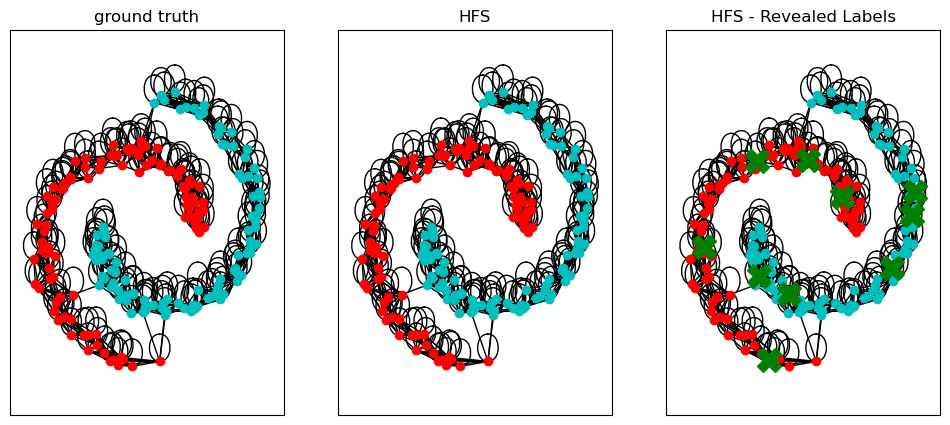

Soft=False, Accuracy=1.0


In [5]:
seed = 42
X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=0, soft=False, dataset='data_2moons_hfs.mat',
                                                 plot=True, seed=seed, **params)

### Question 1.2  - Using `data_2moons_hfs_large.mat`, run `two_moons_hfs` several times with l=4. What can go wrong?

* Tips:
    * When running `two_moons_hfs` several times, don't forget to set `seed=None`

When the number of available labelled points is small (l=4) and the parameter per_class is set to false in the function mask_labels, there is a non-negligible probability that the mask_label function returns 4 points of the same class (the probability is 1/8 for l = 4 with 2 classes). If we get 4 labelled points with the same label "class A", we can't do semi-supervised learning because the classifier chosen by HFS will be a trivial classifier that assigns "class A" to any point in the dataset. 

Moreover, even if we get two classes in the labelled points returned by the mask_label function, the performance of HFS will heavily depend on the position of these labelled points. If the available labeled points are outliers, the information brought by the available labels may be misleading and many points in the dataset may be misclassified by HFS. This did not happen in the 20 iterations of the two_moons_hfs function on the data_2moons_hfs_large.mat dataset because it is a large dataset so it is more unlikely to pick outliers in the labels. However, when doing 20 iterations of the two_moons_hfs function on the data_2moons_hfs.mat dataset (which is smaller) we see that the accuracy of HFS becomes much more variable and dependent on the position of the available labelled points.



In [10]:
mask_labels?

Signature: mask_labels(Y, l, per_class=False)
Docstring:
Function to select a subset of labels and mask the rest.

Parameters
----------
Y : array
    (n,) label vector, where entries Y_i take a value in [1, ..., C] , where C is the number of classes

l : int
    Number of unmasked (revealed) labels to include in the output.

per_class: bool, default: False
    If true, reveal l labels per class, instead of l labels in total.

Returns
-------
Y_masked : array
    (n,) masked label vector, where entries Y_i take a value in [1, ..., C]
    if the node is labeled, or 0 if the node is unlabeled (masked)               
File:      c:\users\jean-\desktop\cours ensae\3a ensae\mva\graph in ml\semi_supervised_learning\helper.py
Type:      function

When doing 20 iterations of the two_moons_hfs function on the data_2moons_hfs_large.mat dataset, the accuracy is good because the dataset is large so it is unlikely to pick an outlier in the available points.

In [21]:
np.random.seed(42)

error_count = 0


for ii in range(20):
    try:
      X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=4, l_noisy=0, soft=False, 
                                                   dataset='data_2moons_hfs_large.mat',
                                                     plot=False, seed=None, **params)

    except AssertionError as e:
       error_count += 1
       continue

print("number of errors because of missing classes over 20 runs of the function",error_count)

Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
number of errors because of missing classes over 20 runs of the function 2


However, when doing 20 iterations of the two_moons_hfs function on the data_2moons_hfs.mat dataset, the accuracy is not as good and can drop to 74% because the dataset is smaller, so it is likely to pick an outlier in the available points.

In [ ]:
# np.random.seed(42)

error_count = 0


for ii in range(20):
    try:
      X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=4, l_noisy=0, soft=False, 
                                                   dataset='data_2moons_hfs.mat',
                                                     plot=False, seed=None, **params)

    except AssertionError as e:
       error_count += 1
       continue

print("number of errors because of missing classes over 20 runs of the function",error_count)

Soft=False, Accuracy=0.99
Soft=False, Accuracy=0.82
Soft=False, Accuracy=0.815
Soft=False, Accuracy=0.875
Soft=False, Accuracy=0.825
Soft=False, Accuracy=0.85
Soft=False, Accuracy=0.74
Soft=False, Accuracy=1.0
Soft=False, Accuracy=1.0
Soft=False, Accuracy=0.835
Soft=False, Accuracy=0.97
Soft=False, Accuracy=0.995
Soft=False, Accuracy=0.86
Soft=False, Accuracy=0.995
Soft=False, Accuracy=0.995
Soft=False, Accuracy=0.85
Soft=False, Accuracy=0.795
Soft=False, Accuracy=0.76
Soft=False, Accuracy=1.0
number of errors because of missing classes over 20 runs of the function 1


### Question 1.3 - Using `data_2moons_hfs.mat`, l=10 and l_noisy=5, compare hard HFS to soft HFS. Report the accuracy and comment the results.

Here we have only 10 available labels and 50% of the labels are noisy. When choosing the appropriate confidence parameter for labelled points for the soft HFS method, we get a much better accuracy with soft HFS than with hard HFS:
- when setting the confidence parameter at c_l = 3 for the soft HFS method, and when running 100 simulations of the two_moons_hfs function, the average accuracy of soft HFS is of 0.91 while the average accuracy of hard HFS is 0.86. 
- for c_l = 3, the standard deviation of the accuracies (on 100 simulations) of soft HFS is similar (or even a bit lower) than that of hard HFS. 

These results are sensible because setting a low value for the confidence parameter of labeled points allows us to take into account noise in the labels, hence the better results for soft HFS. 

We notice that when the value of c_l is too low (close to zero), the accuracy of soft HFS is terrible because we don't use enough the information brought by the labels. If the value of c_l becomes very large, we use too much the information brought by the labels and the performance of soft HFS becomes very similar to that of hard HFS (both in terms of average accuracy and std of the accuracy). Hence, soft HFS can work better than hard HFS, but it requires tuning the confidence parameter c_l and the performance of soft HFS is highly dependent on the value of this parameter. 


In [57]:
# Comparing
# seed = 5  # To run several times with random outcomes, set seed=None. Otherwise, set a seed for reproducibility.

np.random.seed(42)

plot = False 
dataset = 'data_2moons_hfs.mat' # Try also 'data_2moons_hfs_large.mat'

accuracies_soft_means = {}
accuracies_soft_std = {}

accuracies_hard_hfs = []

for confidence_param in np.arange(0.1,30,0.5):
    params['c_l'] = confidence_param
    accuracies_soft_hfs = []
    

    for i in range(100):
        try:
            X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset=dataset,
                                                        plot=plot, seed=None, **params)
            accuracies_hard_hfs.append(hard_accuracy)
        except AssertionError as e:
            continue

        try:
            X, Y, soft_labels, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset=dataset,
                                                        plot=plot, seed=None, **params)
            accuracies_soft_hfs.append(soft_accuracy)
        except AssertionError as e:
            continue

    accuracies_soft_means[confidence_param] = np.mean(accuracies_soft_hfs)
    accuracies_soft_std[confidence_param] = np.std(accuracies_soft_hfs)


Soft=False, Accuracy=0.935
Soft=True, Accuracy=0.905
Soft=False, Accuracy=0.735
Soft=True, Accuracy=0.73
Soft=False, Accuracy=0.825
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.855
Soft=True, Accuracy=0.995
Soft=False, Accuracy=0.54
Soft=True, Accuracy=0.71
Soft=False, Accuracy=0.92
Soft=True, Accuracy=0.675
Soft=False, Accuracy=0.995
Soft=True, Accuracy=0.93
Soft=False, Accuracy=0.78
Soft=True, Accuracy=0.705
Soft=False, Accuracy=0.865
Soft=True, Accuracy=0.91
Soft=False, Accuracy=0.885
Soft=True, Accuracy=0.5
Soft=False, Accuracy=0.91
Soft=True, Accuracy=0.875
Soft=False, Accuracy=0.88
Soft=True, Accuracy=0.68
Soft=False, Accuracy=0.995
Soft=True, Accuracy=0.54
Soft=False, Accuracy=0.885
Soft=True, Accuracy=0.865
Soft=False, Accuracy=0.86
Soft=True, Accuracy=0.775
Soft=False, Accuracy=0.755
Soft=True, Accuracy=0.845
Soft=False, Accuracy=0.755
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.85
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.885
Soft=True, Accuracy=0.835
Soft=False, Ac

Text(0.5, 1.0, 'Average accuracy of soft HFS vs hard HFS (100 simulations)')

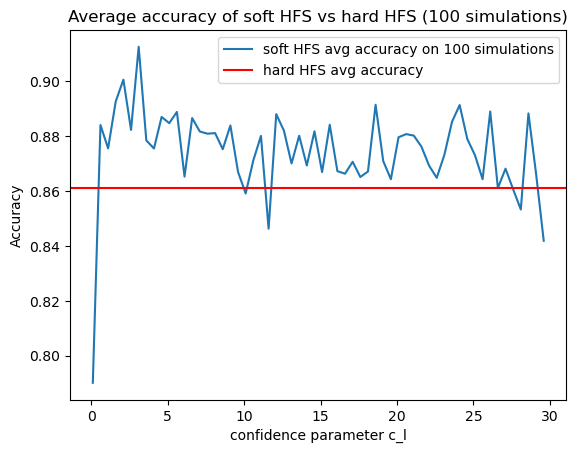

In [58]:
plt.plot(accuracies_soft_means.keys(), accuracies_soft_means.values(),label = "soft HFS avg accuracy on 100 simulations")
plt.axhline(np.mean(accuracies_hard_hfs), label = "hard HFS avg accuracy", color = 'red')
plt.xlabel("confidence parameter c_l")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Average accuracy of soft HFS vs hard HFS (100 simulations)")

Text(0.5, 1.0, 'Std of accuracies of soft HFS vs hard HFS (100 simulations)')

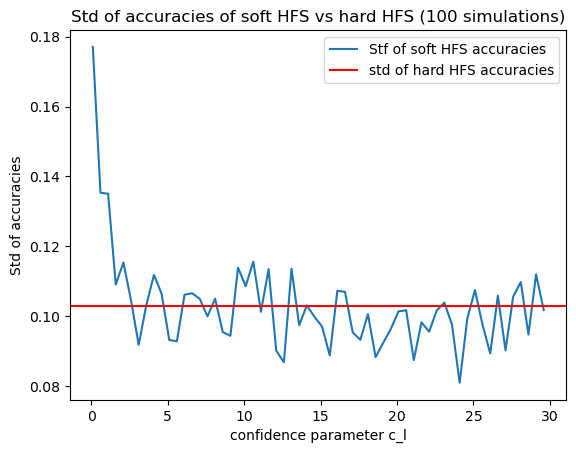

In [59]:
plt.plot(accuracies_soft_std.keys(), accuracies_soft_std.values(),label = "Stf of soft HFS accuracies")
plt.axhline(np.std(accuracies_hard_hfs), label = "std of hard HFS accuracies", color = 'red')
plt.xlabel("confidence parameter c_l")
plt.ylabel("Std of accuracies")
plt.legend()
plt.title("Std of accuracies of soft HFS vs hard HFS (100 simulations)")

On the example below, we clearly see that soft HFS works better than hard HFS (accuracy 0.99 vs 0.94). On the hard HFS plots, we can see several misclassified points at the top of the right moon, because of a noisy label. On the soft HFS plots, there is only one misclassified point at the top of the right moon, suggesting that reducing the confidence of the noisy labels yields better results.

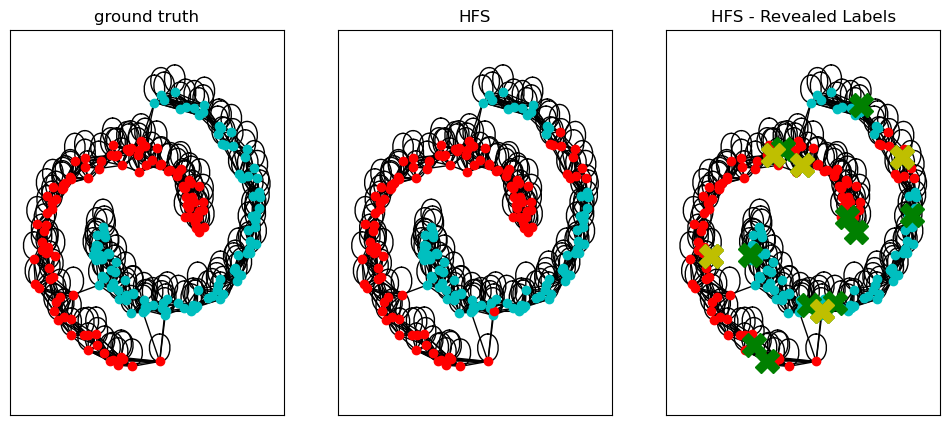

Soft=False, Accuracy=0.94


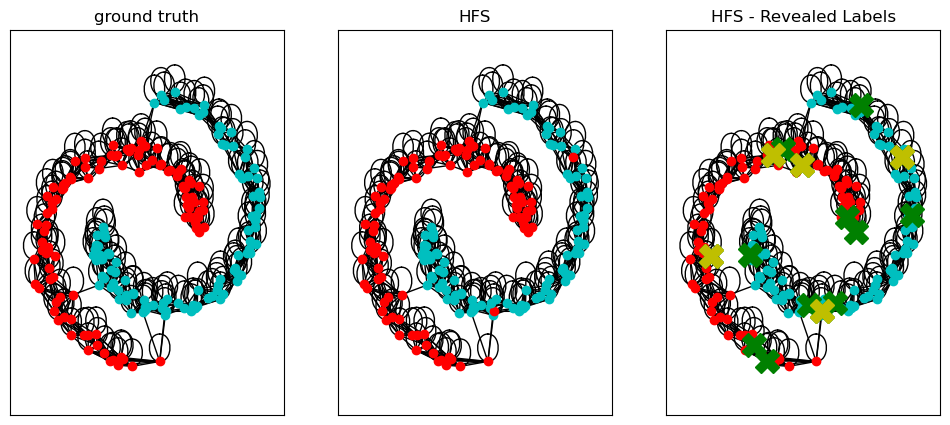

Soft=True, Accuracy=0.99


In [68]:
seed = 47 #46

plot = True
dataset = 'data_2moons_hfs.mat' # Try also 'data_2moons_hfs_large.mat'

params['c_l'] = 3

X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset=dataset,
                                            plot=plot, seed=seed, **params)




X, Y, soft_labels, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset=dataset,
                                            plot=plot, seed=seed, **params)


Interestingly, when running the same experience as above on the large dataset data_2moons_hfs_large.mat, we see that the optimal value for the confidence parameter c_l is much smaller (c_l = 0.1) (don't run the cell below, it took 30 minutes to get the plot). With such a value, we get a better accuracy than on the small dataset (0.93 for the large dataset vs 0.91 for the small dataset). This may be because the graph associated with the large dataset is denser and less sparse, which allows to better exploit the graph structure and to reduce the reliance on the available labelled points.

In [ ]:
# Comparing
# seed = 5  # To run several times with random outcomes, set seed=None. Otherwise, set a seed for reproducibility.

np.random.seed(42)

plot = False 
dataset = 'data_2moons_hfs_large.mat' # Try also 'data_2moons_hfs_large.mat'

accuracies_soft_means = {}
accuracies_soft_std = {}

accuracies_hard_hfs = []

for confidence_param in np.arange(0.1,30,0.5):
    params['c_l'] = confidence_param
    accuracies_soft_hfs = []
    

    for i in range(100):
        try:
            X, Y, hard_labels, hard_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=False, dataset=dataset,
                                                        plot=plot, seed=None, **params)
            accuracies_hard_hfs.append(hard_accuracy)
        except AssertionError as e:
            continue

        try:
            X, Y, soft_labels, soft_accuracy = two_moons_hfs(l=10, l_noisy=5, soft=True, dataset=dataset,
                                                        plot=plot, seed=None, **params)
            accuracies_soft_hfs.append(soft_accuracy)
        except AssertionError as e:
            continue

    accuracies_soft_means[confidence_param] = np.mean(accuracies_soft_hfs)
    accuracies_soft_std[confidence_param] = np.std(accuracies_soft_hfs)
   

Soft=False, Accuracy=0.61
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.85
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.924
Soft=True, Accuracy=0.96
Soft=False, Accuracy=0.898
Soft=True, Accuracy=0.999
Soft=False, Accuracy=0.72
Soft=True, Accuracy=0.833
Soft=False, Accuracy=0.867
Soft=True, Accuracy=0.547
Soft=False, Accuracy=0.917
Soft=True, Accuracy=0.979
Soft=False, Accuracy=0.858
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.907
Soft=True, Accuracy=0.856
Soft=False, Accuracy=0.78
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.97
Soft=True, Accuracy=0.95
Soft=False, Accuracy=0.898
Soft=True, Accuracy=0.724
Soft=False, Accuracy=0.897
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.818
Soft=True, Accuracy=0.999
Soft=False, Accuracy=0.652
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.934
Soft=True, Accuracy=1.0
Soft=False, Accuracy=0.762
Soft=True, Accuracy=0.909
Soft=False, Accuracy=0.822
Soft=True, Accuracy=0.921
Soft=False, Accuracy=0.775
Soft=True, Accuracy=1.0
Soft=False, Accu

Text(0.5, 1.0, 'Average accuracy of soft HFS vs hard HFS (100 simulations on the large dataset)')

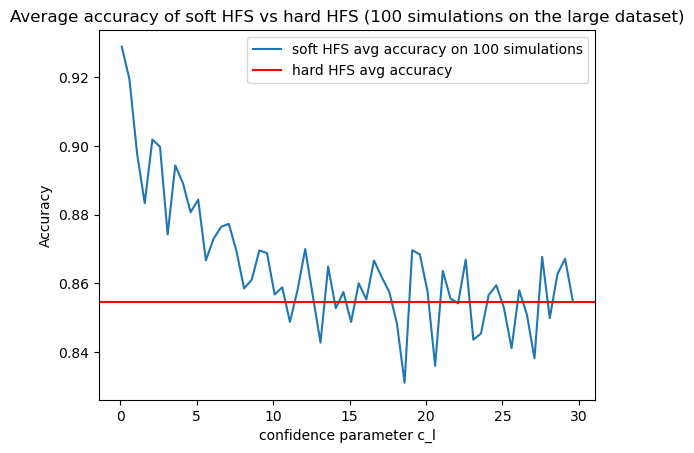

In [ ]:
plt.plot(accuracies_soft_means.keys(), accuracies_soft_means.values(),label = "soft HFS avg accuracy on 100 simulations")
plt.axhline(np.mean(accuracies_hard_hfs), label = "hard HFS avg accuracy", color = 'red')
plt.xlabel("confidence parameter c_l")
plt.ylabel("Accuracy")
plt.legend()    
plt.title("Average accuracy of soft HFS vs hard HFS (100 simulations on the large dataset)")

## 2. Face recognition with HFS

Now, we apply HFS to the task of face recognition, that is, our goal is to classify faces as belonging to different people. Since faces all share common features, it can be a good idea to leverage a large quantity of unlabeled data to improve classification accuracy. In this part of the exercise, you will:

* Extract faces from the images using OpenCV for face detection, and use the same library to apply preprocessing steps;
* Run HFS for classification.

### Implementation

Choose the hyperparameters and run HFS for face recognition, using both the small and large dataset. You can try to change the preprocessing steps (e.g. equalizeHist, GaussianBlur) applied to the images.

**Important**: make sure your HFS code is able to handle more than two classes!

### Question 2.1 - How did you manage to label more than two classes?

In the code for the function compute_hfs, we convert the single vector $Y$ (containing known available labels) into a one-hot-encoding matrix $y$ of with n lines and K columns, where n is the number of nodes/samples and K is the number of classes. The matrix $y$ is made of zeros and ones: 
- $y_{i,j} = 1$ if the label of datapoint $i$ is available and if the label is $j$, 
- $y_{i,j} = 0$ otherwise.

We then compute the hard HFS solution $f$ K times, on each of the K columns of the matrix y: so we get K vectors $f$ corresponding to the solution of hard HFS for each class and merge all these vectors in a matrix of size n x K: $f_{i,j}$ if the score of node $i$ for class $j$. 


For soft HFS, we use linear algebra and get a similar matrix $f$ directly by applying the closed form of the soft HFS solution $f^* = (C^{-1}L+I)^{-1}y
$ to the matrix $y$.

Once we have our matrix $f$, for any node $i$, we assign the class $j$ such that $j = \arg \max_{k \in \{1,\dots,K\}} f_{i,k}$, ie we assign the class $j$ associated with the highest score for node $i$. 


### Question 2.2 - Report the best accuracy you obtained for both (small and augmented) datasets.

To get the best possible accuracy, I used an unnormalized laplacian and a k neighbors graph. Since it is not mentioned that there is noise in the labels, I used hard HFS to avoid having to also tune the confidence parameters of soft HFS. 

#### For the small dataset:

I implemented loops to test the following grid of parameters:
- regularization parameters list = [1e-6,0.01,0.1,0.25]  
- variance parameters list = [10,15,20,25,...,140,145]
- number of neighbors list  = [2,3,4,5,6,7,8,10,15]

I obtained an accuracy of 0.85 with regularization parameter 0.01, variance parameter 70 and 4 neighbors when building the graph. For any given face, the worse accuracy is 0.8 so there is not much variability in the accuracy per face.

#### For the augmented dataset:

I tested a similar grid of parameters but with different values. The best accuracy that I obtained is 0.708 for a regularization of 1e-9, 8 neighbors and a variance of 40. 

### Question 2.3 - If the accuracy changes when using the augmented dataset, explain why. Does using additional data always increase the performance?

We have a lower accuracy on the augmented dataset. There can be several reasons for this: 
- first, although the augmented dataset contains more data, the number of available labels is the same for both datasets. For the small datasets there are 40 known labels for 100 images, for the large dataset there are 40 known labels for 500 images so information on labels is diluted. The graph associated with the large dataset is bigger for the same number of known labels, so information brought by known labels has to be propagated further in the graph, increasing the risk of errors and misclassification compared to the small graph of the small dataset. 
- secondly, there is an increased manifold complexity with the augmented dataset. The large dataset contains more varied images, in terms of angle of photos, light, facial expressions, etc. However there are only 4 known labels per face, so it is likely that these labels do not cover all the variations of each class. For instance if the 4 available labels for a person are front-view images of the person, then a side-view image of the same person may be missclassified because the algorithm will associate this side-view face with the labeled side-view of another person. 
- finally, the euclidean distance may not be the best metric to build the graph of the augmented dataset. For a large heterogeneous dataset with a wide variety of images in terms of light, angle of photo, etc, the distance between pixels of 2 images of the same face may be very large, and even larger than the distance between pixels of the face and another face, although it should not be. 

In [ ]:
# pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.8/40.2 MB 1.6 MB/s eta 0:00:25
    --------------------------------------- 0.8/40.2 MB 1.6 MB/s eta 0:00:25
    --------------------------------------- 0.8/40.2 MB 1.6 MB/s eta 0:00:25
   - -------------------------------------- 1.0/40.2 MB 773.4 kB/s eta 0:00:51
   - -------------------------------------- 1.0/40.2 MB 773.4 kB/s eta 0:00:51
   - -------------------------------------- 1.3/40.2 MB 717.3 kB/s eta 0:00:55
   - -------------------------------------- 1.6/40.2 MB 771.1 kB/s eta 0:00:51
   - -------------------------------------- 1.6/40.2 MB 771.1 kB/s eta 0:00:51
   - --

In [8]:
import matplotlib.pyplot as plt
from imageio import imread
import numpy as np
import cv2
import os

from load_images import load_image_data, plot_image_data
from load_images import load_image_data_augmented, plot_image_data_augmented

In [9]:
"""
Define parameters for face recognition with HFS
"""
params_face_rec = {}
params_face_rec['laplacian_regularization'] = 100
params_face_rec['var'] = 5000.0 #10000
params_face_rec['eps'] = 0
params_face_rec['k'] = 5
params_face_rec['laplacian_normalization'] = 'unn'
params_face_rec['c_l'] = 100
params_face_rec['c_u'] = 0.0001

In [10]:
# Function to preprocess the images
# You may try to change it and check the impact on the classification accuracy
def preprocess_image(image):
    """
    Parameters
    ----------
    image : array
        (width, height) array representing a grayscale image
    
    Returns
    -------
        (96, 96) preprocessed image
    """
    output_frame_size = 96   # do not change the output frame size!
    image = cv2.bilateralFilter(image, 9, 75, 75)
    image = cv2.equalizeHist(image)
    image = cv2.GaussianBlur(image, (5, 5), 0)
    im = cv2.resize(image, (output_frame_size, output_frame_size)).astype(float)
    im -= im.mean()
    im /= im.max()
    image = im
    return image

## For the small dataset

In [11]:
# 10 images per person
np.random.seed(456)   # set seed, since labels are masked randomly
images, labels, masked_labels = load_image_data(preprocess_image)

# # 50 images per person
# images_a, labels_a, masked_labels_a = load_image_data_augmented(preprocess_image)
# plot_image_data_augmented(images_a)

# Uncomment below if you want to visualize the images
# plot_image_data(images)
# print(images.shape)
# print(masked_labels.reshape(-1, 10))

In [81]:
regularization_list = [1e-6,0.01,0.1,0.25] 
var_list = np.arange(10,150,5)
neighbors_list = [2,3,4,5,6,7,8,10,15]

results = []
for reg in regularization_list:
    print(reg)

    params_face_rec['laplacian_regularization'] = reg

    for var in var_list:

        params_face_rec['var'] = var

        for nei in neighbors_list:

            params_face_rec['k'] = nei


            # graph Laplacian
            L = build_laplacian_regularized(images, 
                                            params_face_rec['laplacian_regularization'], 
                                            params_face_rec['var'], 
                                            params_face_rec['eps'], 
                                            params_face_rec['k'], 
                                            params_face_rec['laplacian_normalization'])


            # Run HFS
            predicted_labels, f = compute_hfs(L, masked_labels, soft=False, **params_face_rec)
            accuracy = np.equal(predicted_labels, labels).mean()
            results.append({
                'regularization': reg,
                'var': var,
                'k': nei,
                'accuracy': accuracy
            })

df_results = pd.DataFrame(results)
best_row = df_results.loc[df_results['accuracy'].idxmax()]

print(best_row)

# print(masked_labels)
# print(predicted_labels)
# print(labels)
# # Visualize predicted vs true labels
# plt.subplot(121)
# plt.imshow(labels.reshape((-1, 10)))
# plt.subplot(122)
# plt.imshow(predicted_labels.reshape((-1, 10)))
# plt.title("Accuracy: {}".format(accuracy))
# plt.show()

1e-06
0.01
0.1
0.25
regularization     0.01
var               70.00
k                  4.00
accuracy           0.85
Name: 362, dtype: float64


Accuracy =  0.85
[ 1.  2.  0.  0.  0.  6.  7.  8.  0.  0.  1.  2.  0.  4.  0.  0.  7.  0.
  0.  0.  1.  0.  3.  0.  0.  0.  0.  0.  9.  0.  1.  0.  3.  0.  0.  6.
  0.  0.  9. 10.  0.  0.  0.  4.  5.  6.  0.  8.  0.  0.  0.  0.  0.  4.
  5.  0.  0.  0.  0.  0.  0.  2.  3.  0.  0.  0.  0.  0.  9. 10.  0.  0.
  0.  0.  5.  6.  7.  0.  0. 10.  0.  0.  0.  0.  5.  0.  0.  8.  9. 10.
  0.  2.  3.  4.  0.  0.  7.  8.  0.  0.]
[ 1  2  3  4  5  6  7  8  9 10  1  2  3  4  3  9  7  8  9  9  1  2  3  4
  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9 10  1  2  3  4  5  6 10  8
  1 10 10  2  3  4  5  4  7  8  1 10  1  2  3 10  5  6  7  3  9 10  1  2
 10  4  5  6  7  3  9 10  4  4  3  4  5  6  8  8  9 10  1  2  3  4  5  6
  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9 10  1  2  3  4
  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8
  9 10  1  2  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9 10  1  2
  3  4  5  6  7  8  9 10  1  2  3  4  5  6  7  8  9

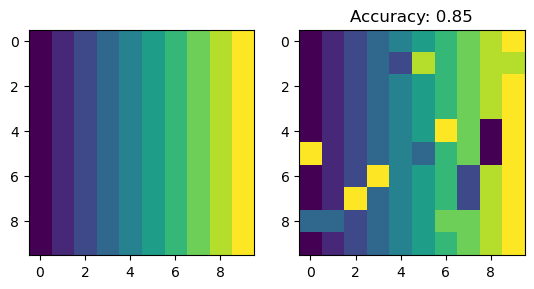

In [84]:
params_face_rec['laplacian_regularization'] =0.01
params_face_rec['var'] = 70.0
params_face_rec['k'] = 4

L = build_laplacian_regularized(images, 
                                params_face_rec['laplacian_regularization'], 
                                params_face_rec['var'], 
                                params_face_rec['eps'], 
                                params_face_rec['k'], 
                                params_face_rec['laplacian_normalization'])


# Run HFS
predicted_labels, f = compute_hfs(L, masked_labels, soft=False, **params_face_rec)
accuracy = np.equal(predicted_labels, labels).mean()
print("Accuracy = ", accuracy)

print(masked_labels)
print(predicted_labels)
print(labels)
# Visualize predicted vs true labels
plt.subplot(121)
plt.imshow(labels.reshape((-1, 10)))
plt.subplot(122)
plt.imshow(predicted_labels.reshape((-1, 10)))
plt.title("Accuracy: {}".format(accuracy))
plt.show()

## For the large dataset

In [86]:
# 10 images per person
np.random.seed(456)   # set seed, since labels are masked randomly
# images, labels, masked_labels = load_image_data(preprocess_image)

# # 50 images per person
images_a, labels_a, masked_labels_a = load_image_data_augmented(preprocess_image)
# plot_image_data_augmented(images_a)

In [105]:
regularization_list = [1e-9,1e-6,0.01]
var_list = np.arange(10,70,10)
neighbors_list = [5,6,7,8,9,10]

results = []
for reg in regularization_list:
    print(reg)

    params_face_rec['laplacian_regularization'] = reg

    for var in var_list:

        params_face_rec['var'] = var

        for nei in neighbors_list:

            params_face_rec['k'] = nei


            # graph Laplacian
            L = build_laplacian_regularized(images_a, 
                                            params_face_rec['laplacian_regularization'], 
                                            params_face_rec['var'], 
                                            params_face_rec['eps'], 
                                            params_face_rec['k'], 
                                            params_face_rec['laplacian_normalization'])


            # Run HFS
            predicted_labels, f = compute_hfs(L, masked_labels_a, soft=False, **params_face_rec)
            accuracy = np.equal(predicted_labels, labels_a).mean()
            results.append({
                'regularization': reg,
                'var': var,
                'k': nei,
                'accuracy': accuracy
            })

df_results = pd.DataFrame(results)
best_row = df_results.loc[df_results['accuracy'].idxmax()]

print(best_row)

# print(masked_labels)
# print(predicted_labels)
# print(labels)
# # Visualize predicted vs true labels
# plt.subplot(121)
# plt.imshow(labels.reshape((-1, 10)))
# plt.subplot(122)
# plt.imshow(predicted_labels.reshape((-1, 10)))
# plt.title("Accuracy: {}".format(accuracy))
# plt.show()

1e-09
1e-06
0.01
regularization    1.000000e-09
var               4.000000e+01
k                 8.000000e+00
accuracy          7.080000e-01
Name: 21, dtype: float64


Accuracy =  0.708
[ 1.  2.  0.  0.  0.  6.  7.  8.  0.  0.  1.  2.  0.  4.  0.  0.  7.  0.
  0.  0.  1.  0.  3.  0.  0.  0.  0.  0.  9.  0.  1.  0.  3.  0.  0.  6.
  0.  0.  9. 10.  0.  0.  0.  4.  5.  6.  0.  8.  0.  0.  0.  0.  0.  4.
  5.  0.  0.  0.  0.  0.  0.  2.  3.  0.  0.  0.  0.  0.  9. 10.  0.  0.
  0.  0.  5.  6.  7.  0.  0. 10.  0.  0.  0.  0.  5.  0.  0.  8.  9. 10.
  0.  2.  3.  4.  0.  0.  7.  8.  0.  0.]
[ 1  2  3  4  7  6  3  8  9 10  1  3  3  4  5  6  7  7  7 10  1  2  3  4
  7  6  7  8  9  4  1  7  3  4  5  6  7  7  9  3  1  7  3  4  5  7  7  3
  9 10  4  3  3  4  5  6  7  8  9  4  1  7  3  4  5  6  7  3  7  6  1  2
  3  7  5  9  7  8  9  4  1  2  3  3  5  6  7  8  9  4  1  6  3  4  7  9
  7  7  9  6  4  7  3  7  5  9  7  7  9 10  1  3  3  4  5  7  7  8  9  6
  1  2  3  4  5  6  7  3  9 10  1  2  3  7  5  6  7  8  9 10  1  3  3  4
  5  6  7  7  9 10  1  4  3  4  5  6  7  8  9 10  1  7  3  7  5  6  7  8
  9  4  1  4  4  4  7  6  6  7  9 10  1  7  3  3  5  6  7  8  9 

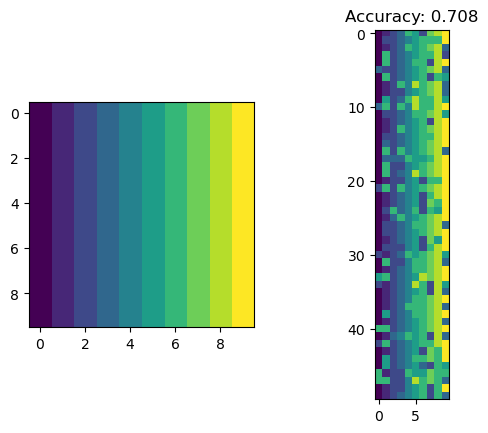

In [106]:
params_face_rec['laplacian_regularization'] = 1e-9
params_face_rec['var'] = 40.0
params_face_rec['k'] = 8

L = build_laplacian_regularized(images_a, 
                                params_face_rec['laplacian_regularization'], 
                                params_face_rec['var'], 
                                params_face_rec['eps'], 
                                params_face_rec['k'], 
                                params_face_rec['laplacian_normalization'])


# Run HFS
predicted_labels, f = compute_hfs(L, masked_labels_a, soft=False, **params_face_rec)
accuracy = np.equal(predicted_labels, labels_a).mean()
print("Accuracy = ", accuracy)

print(masked_labels)
print(predicted_labels)
print(labels)
# Visualize predicted vs true labels
plt.subplot(121)
plt.imshow(labels.reshape((-1, 10)))
plt.subplot(122)
plt.imshow(predicted_labels.reshape((-1, 10)))
plt.title("Accuracy: {}".format(accuracy))
plt.show()

## 3. Online SSL

Now, instead of having all the data available at once, images will be received online: at each time $t$, a new image $x_t$ is observed and the algorithm has to output a label $y_t$. 

Use the function `create_user_profile` to capture a training set of labeled data (of your face and someone else). The faces will be preprocessed and saved in the folder `data/faces`. They will be loaded by `online_face_recognition`.


### Implementation

Choose the hyperparameters and complete the functions `online_ssl_update_centroids` and `online_ssl_compute_solution`. 

Modify your code to be able to disregard faces it cannot recognize.

* Tips:
    * You can use the functions `build_similarity_graph` and `build_laplacian`.

### Question 3.1 - Attach to this notebook some of the resulting frames of online face recognition. 

Notice that the face detection algorithm also detects random spots in the background of the video. 

![title](AG1.png)
![title](AG2.png)
![title](AG3.png)
![title](GG1.png)
![title](GG2.png)
![title](GG3.png)


### Question 3.2 - What strategy did you use to label a face as unknown? Attach to this notebook an example of a unknown face being correctly labeled as unknown.

Whenever a face has a score lower than 0.2, my strategy was to label it as unknown, as it is unlikely that it corresponds to the face of one of the two actors for whom I collected labels. The score threshold 0.2 was tuned iteratively: a threshold of 0.5 was too large and led to faces of the two known actors being labeled as unknown. 

![title](uknown1.png)
![title](unknown2.png)


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import os
import sys
from scipy.spatial import distance
import scipy.io as sio

from helper_online_ssl import create_user_profile, online_face_recognition

In [13]:
"""
Define parameters for face recognition with HFS
"""
params_online_ssl = {}
params_online_ssl['laplacian_regularization'] = 0.1
params_online_ssl['var'] = 100
params_online_ssl['eps'] = 0
params_online_ssl['k'] = 5
params_online_ssl['laplacian_normalization'] = 'unn'
params_online_ssl['c_l'] = None
params_online_ssl['c_u'] = None

In [14]:
class IncrementalKCenters:
    def __init__(self, labeled_faces, labels, label_names, max_num_centroids=50):
        #  Number of labels
        self.n_labels = max(labels)

        #  Dimension of the input image
        self.image_dimension = labeled_faces.shape[1]

        #  Check input validity
        assert (set(labels) == set(
            range(1, 1 + self.n_labels))), "Initially provided faces should be labeled in [1, max]"
        assert (len(labeled_faces) == len(labels)), "Initial faces and initial labels are not of same size"

        #  Number of labelled faces
        self.n_labeled_faces = len(labeled_faces)

        # Model parameter : number of maximum stored centroids
        self.max_num_centroids = max_num_centroids

        # Model centroids (inital labeled faces). Shape = (number_of_centroids, dimension)
        self.centroids = labeled_faces

        # Centroids labels
        self.Y = labels
        
        # Label names (= user names)
        self.label_names = label_names

        # Variables that are initialized in online_ssl_update_centroids()
        self.centroids_distances = None
        self.taboo = None
        self.V = None
        self.init = True

        # index of x_t (initialized later)
        self.last_face = None
    
    def initialize(self):
        """
        Initialization after the first time that the maximum number of centroids is reached.
        """       
        #  Compute the centroids distances
        self.centroids_distances = distance.cdist(self.centroids, self.centroids)

        #  set labeled nodes and self loops as infinitely distant, to avoid merging labeled centroids
        np.fill_diagonal(self.centroids_distances, +np.inf)
        self.centroids_distances[0:self.n_labeled_faces, 0:self.n_labeled_faces] = +np.inf

        # put labeled nodes in the taboo list
        self.taboo = np.array(range(self.centroids.shape[0])) < self.n_labeled_faces

        # initialize multiplicity
        self.V = np.ones(self.centroids.shape[0])


    def online_ssl_update_centroids(self, face):
        """
        TO BE COMPLETED

        Update centroids, multiplicity vector V, labels Y.
        
        Note: In Y, set label to 0 for unlabeled faces.

        Parameters
        ----------
        face : array
            New sample
        
        Returns
        --------
        List with the scores for each possible label:
            [(label_1, score_1), (label_2, score_2), ...]
        """

        assert (self.image_dimension == len(face)), "new image not of good size"

        # Case 1: maximum number of centroids has been reached.
        if self.centroids.shape[0] >= self.max_num_centroids + 1:
            if self.init:
                #  Initialization after the first time that the maximum number of centroids is reached
                self.initialize()
                self.init = False
            """
            Find c_rep and c_add following Algorithm 1.
            
            - c_1, c_2 = two closest centroids (minimum distance) such that at least one of them is not in self.taboo.
            - c_rep = centroid in {c_1, c_2} that is in self.taboo. If none of them is in self.taboo, c_rep is the one
                      with largest multiplicity.
            - c_add = centroid in {c_1, c_2} that is not c_rep.
            """

            taboo_indices = np.where(self.taboo)[0]
            self.centroids_distances[np.ix_(taboo_indices, taboo_indices)] = np.inf
            min_idx = np.argmin(self.centroids_distances)
            c1, c2 = np.unravel_index(min_idx, self.centroids_distances.shape)
            
            c_rep, c_add = None, None

            # ...
            if self.taboo[c1]:
                c_rep = c1
                c_add = c2
            elif self.taboo[c2]:
                c_rep = c2
                c_add = c1
            elif self.V[c2] <= self.V[c1]:
                c_rep = c1
                c_add = c2
            else:
                c_rep = c2
                c_add = c1

            """
            Update data structures: self.centroids and self.V
            """
            # ...
            self.V[c_rep] = self.V[c_rep] + self.V[c_add]
            self.centroids[c_add] = face
            self.V[c_add] = 1
            self.Y[c_add] = 0

            """
            Update the matrix containing the distances.
            """
            dist_row = distance.cdist(np.array([self.centroids[c_add]]), self.centroids)[0]
            dist_row[c_add] = +np.inf
            self.centroids_distances[c_add, :] = dist_row
            self.centroids_distances[:, c_add] = dist_row
            self.last_face = c_add

        # Case 2: create new centroid with face
        # Remark: the multiplicities vector self.V is initialized in self.initialize()
        else:
            current_len = len(self.centroids)
            self.Y = np.append(self.Y, 0)
            self.centroids = np.vstack([self.centroids, face])

    def online_ssl_compute_solution(self):
        """
        TO BE COMPLETED.

        Returns a prediction corresponding to self.last_face.
        """

        # Multiplicity matrix
        if self.init:
            V = np.diag(np.ones(self.centroids.shape[0]))
            self.last_face = self.centroids.shape[0] - 1
        else:
            V = np.diag(self.V)
            
        # Build quantized graph and its regularized Laplacian

        W_tilde = build_similarity_graph(self.centroids, 
                                   var=params_online_ssl['var'], 
                                   eps=params_online_ssl['eps'], 
                                   k=params_online_ssl['k'])
        W = V @ W_tilde @ V
        L = build_laplacian(W, params_online_ssl['laplacian_normalization'])
        Q = L + params_online_ssl['laplacian_regularization'] * np.eye(L.shape[0])

        # Compute the hard HFS solution f. 
        labels, f = compute_hfs(Q, self.Y, soft=False, **params_online_ssl)

        # Return the score for each possible label
        num_classes = len(np.unique(self.Y))-1 
        label_scores = []
        for ii in range(num_classes):
            label = self.label_names[ii]
            score = f[self.last_face, ii]
            label_scores.append((label, score))
        
        # handle unknown faces
        # ...
        max_score = max([s for _, s in label_scores]) if label_scores else 0
        if max_score < 0.2:
            return [("unknown", 0.0)]

        return label_scores
      


In [ ]:
# create_user_profile('Greg Guillotin',video_filename = 'Entre 2 Tours.mp4')         # choose your names here :)
create_user_profile('Aude Gogny',video_filename = 'Entre 2 Tours.mp4')


Profile found with 6 images.
Image 7 saved at data/faces\Aude Gogny\img_7.bmp
Image 8 saved at data/faces\Aude Gogny\img_8.bmp
Image 9 saved at data/faces\Aude Gogny\img_9.bmp
Image 10 saved at data/faces\Aude Gogny\img_10.bmp
Image 11 saved at data/faces\Aude Gogny\img_11.bmp
Image 12 saved at data/faces\Aude Gogny\img_12.bmp
Image 13 saved at data/faces\Aude Gogny\img_13.bmp
Image 14 saved at data/faces\Aude Gogny\img_14.bmp
Image 15 saved at data/faces\Aude Gogny\img_15.bmp
Image 16 saved at data/faces\Aude Gogny\img_16.bmp
Image 17 saved at data/faces\Aude Gogny\img_17.bmp
Image 18 saved at data/faces\Aude Gogny\img_18.bmp
Image 19 saved at data/faces\Aude Gogny\img_19.bmp


In [9]:
online_face_recognition(['Aude Gogny','Greg Guillotin'], IncrementalKCenters, n_pictures=9,video_filename = 'Entre 2 Tours.mp4')

Profile found with 9 images.
Profile found with 23 images.


### Question 4.1 - You can now classify faces as either known (i.e. belong to a class) or unknown (i.e. belong to no class). How would you modify the algorithm to automatically learn to classify new classes? That is, how can you modify the algorithm so that faces that appear unfrequently are labeled as unknown, but once a specific face has been seen enough times it gets assigned an automatic label (e.g. AutoBob) and from that point it is treated as a new class. 

In the previous question, I already added a confidence threshold for the score of the incoming face: if the score is below this given confidence threshold (0.2 in my code), the face is labelled as unknown. To be able to automatically classify the unknown faces, we also need to add a multiplicity threshold: once a centroid containing unlabelled faces has a multiplicity above this multiplicity threshold, the algorithm should assign the label AutoBob to this centroid and add it to the taboo list. 

For instance, if we keep the confidence threshold 0.2 and set the multiplicity threshold at 100:
- when an image of a new face arrives, if its score is below the confidence threshold, ie if it is very different of already seen faces, this new face will be added to a new centroid, with multiplicity 1. 
- as more images of this new face arrive, they are added to the new centroid and its multiplicity increases. Once the multiplicity threshold of 100 has been exceeded (because we have seen 100 images of the new face, or less if we have assigned other people's face to this centroid), we create a new label for this centroid associated with the new face. And we add the newly labelled centroid to the taboo list, to ensure it won't be merged into another centroid. 
    
I've modified the class below to take these modifications into account: I've kept the confidence threshold at 0.2 and I've set arbitrarily the multiplicity threshold at 50. 

In [15]:
class IncrementalKCenters_auto:
    def __init__(self, labeled_faces, labels, label_names, max_num_centroids=50):
        #  Number of labels
        self.n_labels = max(labels)

        #  Dimension of the input image
        self.image_dimension = labeled_faces.shape[1]

        #  Check input validity
        assert (set(labels) == set(
            range(1, 1 + self.n_labels))), "Initially provided faces should be labeled in [1, max]"
        assert (len(labeled_faces) == len(labels)), "Initial faces and initial labels are not of same size"

        #  Number of labelled faces
        self.n_labeled_faces = len(labeled_faces)

        # Model parameter : number of maximum stored centroids
        self.max_num_centroids = max_num_centroids

        # Model centroids (inital labeled faces). Shape = (number_of_centroids, dimension)
        self.centroids = labeled_faces

        # Centroids labels
        self.Y = labels
        
        # Label names (= user names)
        self.label_names = label_names

        # Variables that are initialized in online_ssl_update_centroids()
        self.centroids_distances = None
        self.taboo = None
        self.V = None
        self.init = True

        # index of x_t (initialized later)
        self.last_face = None
    
    def initialize(self):
        """
        Initialization after the first time that the maximum number of centroids is reached.
        """       
        #  Compute the centroids distances
        self.centroids_distances = distance.cdist(self.centroids, self.centroids)

        #  set labeled nodes and self loops as infinitely distant, to avoid merging labeled centroids
        np.fill_diagonal(self.centroids_distances, +np.inf)
        self.centroids_distances[0:self.n_labeled_faces, 0:self.n_labeled_faces] = +np.inf

        # put labeled nodes in the taboo list
        self.taboo = np.array(range(self.centroids.shape[0])) < self.n_labeled_faces

        # initialize multiplicity
        self.V = np.ones(self.centroids.shape[0])


    def online_ssl_update_centroids(self, face):
        """
        TO BE COMPLETED

        Update centroids, multiplicity vector V, labels Y.
        
        Note: In Y, set label to 0 for unlabeled faces.

        Parameters
        ----------
        face : array
            New sample
        
        Returns
        --------
        List with the scores for each possible label:
            [(label_1, score_1), (label_2, score_2), ...]
        """

        assert (self.image_dimension == len(face)), "new image not of good size"

        # Case 1: maximum number of centroids has been reached.
        if self.centroids.shape[0] >= self.max_num_centroids + 1:
            if self.init:
                #  Initialization after the first time that the maximum number of centroids is reached
                self.initialize()
                self.init = False
            """
            Find c_rep and c_add following Algorithm 1.
            
            - c_1, c_2 = two closest centroids (minimum distance) such that at least one of them is not in self.taboo.
            - c_rep = centroid in {c_1, c_2} that is in self.taboo. If none of them is in self.taboo, c_rep is the one
                      with largest multiplicity.
            - c_add = centroid in {c_1, c_2} that is not c_rep.
            """

            taboo_indices = np.where(self.taboo)[0]
            self.centroids_distances[np.ix_(taboo_indices, taboo_indices)] = np.inf
            min_idx = np.argmin(self.centroids_distances)
            c1, c2 = np.unravel_index(min_idx, self.centroids_distances.shape)
            
            c_rep, c_add = None, None

            # ...
            if self.taboo[c1]:
                c_rep = c1
                c_add = c2
            elif self.taboo[c2]:
                c_rep = c2
                c_add = c1
            elif self.V[c2] <= self.V[c1]:
                c_rep = c1
                c_add = c2
            else:
                c_rep = c2
                c_add = c1

            """
            Update data structures: self.centroids and self.V
            """
            # ...
            self.V[c_rep] = self.V[c_rep] + self.V[c_add]
            for i in range(len(self.centroids)):
                if self.Y[i] == 0 and self.V[i] >= 15:
                    new_label = len(self.label_names) + 1
                    new_name = f"Auto_{new_label}"
                    self.Y[i] = new_label
                    self.label_names.append(new_name)
                    self.taboo[i] = True 
            self.centroids[c_add] = face
            self.V[c_add] = 1
            self.Y[c_add] = 0

            """
            Update the matrix containing the distances.
            """
            dist_row = distance.cdist(np.array([self.centroids[c_add]]), self.centroids)[0]
            dist_row[c_add] = +np.inf
            self.centroids_distances[c_add, :] = dist_row
            self.centroids_distances[:, c_add] = dist_row
            self.last_face = c_add

        # Case 2: create new centroid with face
        # Remark: the multiplicities vector self.V is initialized in self.initialize()
        else:
            current_len = len(self.centroids)
            self.Y = np.append(self.Y, 0)
            self.centroids = np.vstack([self.centroids, face])

    def online_ssl_compute_solution(self):
        """
        TO BE COMPLETED.

        Returns a prediction corresponding to self.last_face.
        """

        # Multiplicity matrix
        if self.init:
            V = np.diag(np.ones(self.centroids.shape[0]))
            self.last_face = self.centroids.shape[0] - 1
        else:
            V = np.diag(self.V)
            
        # Build quantized graph and its regularized Laplacian

        W_tilde = build_similarity_graph(self.centroids, 
                                   var=params_online_ssl['var'], 
                                   eps=params_online_ssl['eps'], 
                                   k=params_online_ssl['k'])
        W = V @ W_tilde @ V
        L = build_laplacian(W, params_online_ssl['laplacian_normalization'])
        Q = L + params_online_ssl['laplacian_regularization'] * np.eye(L.shape[0])

        # Compute the hard HFS solution f. 
        labels, f = compute_hfs(Q, self.Y, soft=False, **params_online_ssl)

        # Return the score for each possible label
        num_classes = len(np.unique(self.Y))-1 
        label_scores = []
        for ii in range(num_classes):
            label = self.label_names[ii]
            score = f[self.last_face, ii]
            label_scores.append((label, score))
        
        # handle unknown faces
        # ...
        max_score = max([s for _, s in label_scores]) if label_scores else 0
        if max_score < 0.2:
            return [("unknown", 0.0)]

        return label_scores
      


In [29]:
online_face_recognition(['Aude Gogny','Greg Guillotin'], IncrementalKCenters_auto, n_pictures=9,video_filename = 'Entre 2 Tours.mp4')

Profile found with 9 images.
Profile found with 23 images.


However, the modifications are not yielding very effective results. But I believe this is mostly caused by the video and by the face detection algorithm, not by the modifications themselves.

On the first image below, the face detection classifier haarcascade detects some faces in the background very often. As a result, for some spots in the background that are very often associated to faces, our modified IncrementalKCenters_auto class ends up assigning new labels to random spots in the background.
![title](failauto.png)

Another issue is that the second actor wears glasses: this is a big issue for face detection because glasses create reflects that perturbate eyes detection, making it impossible to assign all the images of the face of this actor in a single centroid. This results in the IncrementalKCenters_auto class not assigning a label to this actor. 
![title](failauto2.png)


In [39]:
online_face_recognition(['Aude Gogny'], IncrementalKCenters_auto, n_pictures=9,video_filename = 'Entre 2 Tours.mp4')

Profile found with 9 images.


However, when removing one of the "easy to detect actors" of the known labeled faces, we manage to label it automatically after some time, which shows that our modifications work, although they require tuning thoughtfully the thresholds to avoid labeling too many random spots in the background. 

![title](autofonctionne.png)

### Question 4.2 - In class we considered different kinds of metric for (semi) supervised learning. Looking at the face classification task, try to quantify how the offline-online, exact-quantized, and inductive-transductive axes influence each other. In particular given $l$ labeled faces, $u = N - l$ unlabeled faces, and $m$ extra/test faces design an experimental study to quantify these trade-offs, both in terms of transductive and inductive error, as well as online/batch error. Examples of combinations that can be used to study these axes are:
* Supervised vs Semi-supervised
    * A comparison between a supervised learner (of your choice) trained on the $l$ labeled faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces.
* Inductive vs Transductive
    * A comparison between a supervised learner (of your choice) trained on the $l$ labeled faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces evaluated on the $N$ revealed points and then on the $m$ unrevealed points.
* Supervised vs Semi-supervised and Inductive vs Transductive
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces and a semi-supervised learner (of your choice) trained on the $l + u$ labeled and unlabeled faces, evaluated on the $N$ revealed points and then on the $m$ unrevealed points.
* Online vs Batch
    * A comparison between a supervised learner (of your choice) trained on the $N$ labeled faces and an online supervised learner (of your choice) trained revealing the $N$ labels one at a time
* Exact vs Quantized
    * A comparison between a semi-supervised learner (of your choice) trained on the $N$ labeled and unlabeled (you reveal everything here) faces using a certain memory budget, and the same learner with a constrained memory budget.
* Exact vs Quantized and Online vs Batch and Inductive vs Transductive
    * A comparison between a semi-supervised online learner (of your choice) trained with and without quantization, evaluated both on the $N$ faces revealed during training, and $m$ faces unrevealed. You can further compare the online performance of the learner against the performance of an "hindsight" learner that saw the labels all at once

# Supervised vs semi-supervised (on the whole dataset)

In the code below, I compare:
- a KNN trained only on the $l = 40$ available labeled faces. I've set the number of neighbors to 3 because there are 4 available faces per person. 
- a SVM with rbf kernel trained only on the $l$ available labeled faces. 
- the Hard HFS trained on the $l+u$ unlabelled faces. 
- a KNN trained on all the data (called oracle KNN below). I've kept the number of neighbors to 3 (we could set the number of neighbors to 9 here because there are 10 available faces per person, but doing this reduces the accuracy of the classifier because for a given face, some of the more distant neighbors are faces of other persons). 
- a SVM trained on all the data (called oracle SVM below).

I've trained these models 100 times and computed the accuracy of each of them on all the small dataset of faces (used in part 2 of the notebook) for each of these simulations. The plot below shows the accuracy per simulation, per model (left plot) and a boxplot of the statistics of the accuracy over the 100 simulations, per model (right plot). We can see that: 
- the KNN trained only on the $l = 40$ available labels has a lower accuracy than Hard HFS (0.67 vs 0.85): this shows that SSL works and that we can get a better accuracy by exploiting a graph structure. 
- surprisingly, the SVM trained only on the $l = 40$ available labels has a very similar accuracy to that of HFS (0.86 vs 0.85). This is all the more surprising as I spent a long time in question 2 choosing the parameters for building the graph, so I don't think that this is related to a poor graph structure when building the graph for HFS. This result could be explained by the fact that data is easily linearly separated (?). This suggests that SSL is not always the best solution if the data has an easy structure ? 
- In terms of variability of accuracy: SVM trained on the $40$ datapoints has a slightly lower standard deviation of accuracies over the 100 simulations than HFS, which itself has a better std of accuracies than KNN trained on the $40$ datapoints. This could confirm that SSL is not always the best solution if we have easy data.  
- The oracle SVM has a perfect accuracy (equal to 1): when comparing it with the average accuracy of HFS at 0.85, we can deduce from  this that the graph structure does not perfectly exploit the topology of the classes. 
- The oracle KNN has an accuracy of 0.89, close to that of HFS. Since the oracle KNN was trained with a number of neighbors set to 3, it means that for some missclassified faces, 2 or 3 out of the 3 closest neighbors faces are faces from other persons, explaining the misclassification. This also explains why the HFS does some classification errors, since it is based on a KNN graph. 



In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [40]:

params_face_rec = {}
params_face_rec['laplacian_regularization'] = 0.01
params_face_rec['var'] = 70.0
params_face_rec['eps'] = 0
params_face_rec['k'] = 4
params_face_rec['laplacian_normalization'] = 'unn'
params_face_rec['c_l'] = 100
params_face_rec['c_u'] = 0.0001

          
simus = 100       
SEED = 42


np.random.seed(SEED)
images, labels, masked_labels_default = load_image_data(preprocess_image)


acc_knn   = []   # accuracy of KNN trained only on labeled data
acc_svm = []     #idem for SVM
acc_knn_N   = []   # accuracy of KNN trained on all data = oracle 
acc_svm_N = [] #idem for svm
acc_hfs_lu  = []   # HFS trained on labled and unlablled data

for run in range(simus):
    np.random.seed(SEED + run)

  
    Y_masked = mask_labels(labels, l=4, per_class=True)

    l_idx = np.where(Y_masked > 0)[0]   
    u_idx = np.where(Y_masked == 0)[0]  

    X_labeled = images[l_idx]
    y_labeled = labels[l_idx]
    X_all = images
    y_all = labels

    #training of KNN only on slabeled data
    knn = KNeighborsClassifier(nei)
    knn.fit(X_labeled, y_labeled)
    pred_knn = knn.predict(X_all)
    acc_knn.append(accuracy_score(y_all, pred_knn))

    #training of svm 
    svm = SVC(kernel = 'rbf', C=10, gamma = 'scale')
    svm.fit(X_labeled,y_labeled)
    pred_svm = svm.predict(X_all)
    acc_svm.append(accuracy_score(y_all, pred_svm))

    # HFS 
    L = build_laplacian_regularized(
        X_all,
        laplacian_regularization=params_face_rec['laplacian_regularization'],
        var=params_face_rec['var'],
        eps=params_face_rec['eps'],
        k=params_face_rec['k'],
        laplacian_normalization=params_face_rec['laplacian_normalization']
    )

    pred_hfs, zz = compute_hfs(L, Y_masked, **params_face_rec)
    acc_hfs_lu.append(accuracy_score(y_all, pred_hfs))

    #oracle knn
    knn_N = KNeighborsClassifier(n_neighbors=3)
    knn_N.fit(X_all, y_all)
    pred_knn_N = knn_N.predict(X_all)
    acc_knn_N.append(accuracy_score(y_all, pred_knn_N))

    #oracle svm
    svm_N = SVC(kernel = 'rbf', C=10, gamma = 'scale')
    svm_N.fit(X_all,y_all)
    pred_svm_N = svm_N.predict(X_all)
    acc_svm_N.append(accuracy_score(y_all, pred_svm_N))

    

print('KNN trained only on available labels, mean and std',np.mean(acc_knn),np.std(acc_knn))
print('SVM trained only on available labels, mean and std',np.mean(acc_svm),np.std(acc_svm))
print('HFS, mean and std',np.mean(acc_hfs_lu),np.std(acc_hfs_lu))
print('Oracle KNN trained on all data, mean and std',np.mean(acc_knn_N),np.std(acc_knn_N))
print('Oracle SVM trained on all data, mean and std',np.mean(acc_svm_N),np.std(acc_svm_N))

KNN trained only on available labels, mean and std 0.6657 0.04273768828563379
SVM trained only on available labels, mean and std 0.8638999999999999 0.02835119045119624
HFS, mean and std 0.8496999999999999 0.02655014124256216
Oracle KNN trained on all data, mean and std 0.8900000000000001 1.1102230246251565e-16
Oracle SVM trained on all data, mean and std 1.0 0.0


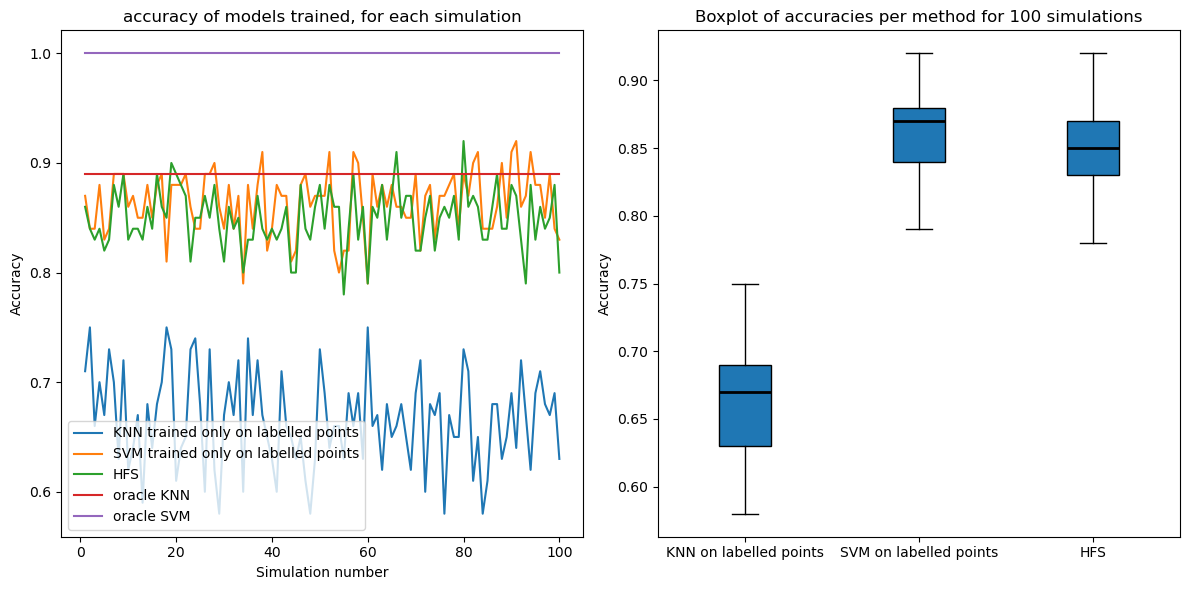

In [42]:
fig, axes = plt.subplots(1,2,figsize = (12,6))

runs = np.arange(1, simus + 1)

ax = axes[0]

# plot all classifiers
ax.plot(runs, acc_knn,label='KNN trained only on labelled points')
ax.plot(runs, acc_svm,label='SVM trained only on labelled points')
ax.plot(runs, acc_hfs_lu, label='HFS')
ax.plot(runs, acc_knn_N, label='oracle KNN')
ax.plot(runs, acc_svm_N, label='oracle SVM')
ax.set_xlabel('Simulation number')
ax.set_ylabel('Accuracy')
ax.set_title('accuracy of models trained, for each simulation')
ax.legend()

#boxplot
ax1 = axes[1]
data_to_plot = [acc_knn, acc_svm ,acc_hfs_lu]
labels_plot  = [f'KNN on labelled points', 'SVM on labelled points','HFS']

bp = ax1.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

ax1.set_xticklabels(labels_plot)
ax1.set_ylabel('Accuracy')
ax1.set_title('Boxplot of accuracies per method for 100 simulations')

plt.tight_layout()
plt.show()

# Inductive vs Transductive

To compare inductive and transductive accuracy, I trained HFS on 80 train images of the faces dataset ($l = 40$ labeled and $u=40$ unlabeled points), SVM and KNN on $l = 40$ datapoints and I kept aside $m = 20$ points that have not been seen by any model for inductive accuracy. 
- Transductive accuracy is measured on the 40 unlabeled points that have been seen by the HFS model. 
- Inductive accuracy will be computed by using the following formula for labeling the $m = 20$ points that were not seen by HFS:
$$f_i = \frac{\sum_{j=1}^n w_{i,j} f_j}{\sum_{j=1}^n w_{i,j}}$$
Where $f_i$ is the score of any point $i$ not seen by HFS, $w_{i,j}$ is the weight between point $i$ and any point $j$ that was seen by HFS and $f_j$ is the score of any point $j$ seen by HFS. 

From the code below, we see that: 
- inductive and transductive accuracy are extremely similar for KNN and SVM, which is normal because both errors can be viewed as test errors since KNN and SVM did no see any of the $u$ or $m$ datapoints used to compute inductive and transductive accuracy. 
- For HFS, average transductive accuracy is at 0.74, average inductive accuracy is at 0.73 so the inductive extension that we implemented with the formula above works very well (although SVM performs better in this case).
- For HFS, the standard deviation over 100 simulations of transductive accuracy is of 0.05 while it is of 0.01 for inductive accuracy. This makes sense because the $m$ points used to compute inductive accuracy can introduce outliers, which results in a larger accuracy variance compared to transductive accuracy.  

In [ ]:

params_face_rec = {}
params_face_rec['laplacian_regularization'] = 0.01
params_face_rec['var'] = 70.0
params_face_rec['eps'] = 0
params_face_rec['k'] = 4
params_face_rec['laplacian_normalization'] = 'unn'
params_face_rec['c_l'] = 100
params_face_rec['c_u'] = 0.0001

In [61]:
simus = 100       
SEED = 42

np.random.seed(SEED)
images, labels, masked_labels_default = load_image_data(preprocess_image)

acc_knn_ind   = []
acc_svm_ind   = []
acc_hfs_ind   = []

acc_knn_trans = []
acc_svm_trans = []
acc_hfs_trans = []

for run in range(simus):
    np.random.seed(SEED + run)
    N = 100
    m_test = 20
    test_idx = np.random.choice(N, m_test, replace=False)
    train_idx = np.setdiff1d(np.arange(N), test_idx)

    X_train, y_train = images[train_idx], labels[train_idx]
    X_test,  y_test  = images[test_idx],  labels[test_idx]

    Y_masked_train = mask_labels(y_train, l=4, per_class=True)
    l_idx = np.where(Y_masked_train > 0)[0]
    u_idx_train = np.where(Y_masked_train == 0)[0]

    # transductive learning on HFS, on l+u 
    L_train = build_laplacian_regularized(
        X_train,
        laplacian_regularization=params_face_rec['laplacian_regularization'],
        var=params_face_rec['var'],
        eps=params_face_rec['eps'],
        k=params_face_rec['k'],
        laplacian_normalization=params_face_rec['laplacian_normalization']
    )
    
    pred_train_hfs, f_train = compute_hfs(L_train, Y_masked_train, **params_face_rec)

    # Transductive error HFS
    acc_hfs_trans.append(accuracy_score(y_train[u_idx_train], pred_train_hfs[u_idx_train]))


    # inductive extension with formula above
    dist_sq = distance.cdist(X_test, X_train, metric='sqeuclidean')
    
    W_test_train = np.exp(-dist_sq / params_face_rec['var'])
    
    k_val = params_face_rec.get('k', 0)
    if k_val is not None and k_val > 0:
        indices_to_zero = np.argsort(W_test_train, axis=1)[:, :-k_val]
        np.put_along_axis(W_test_train, indices_to_zero, 0, axis=1)

    num = W_test_train @ f_train
    den = np.sum(W_test_train, axis=1, keepdims=True)
    den[den == 0] = 1e-10  
    
    f_test = num / den
    pred_test_hfs = np.argmax(f_test, axis=1) + 1 

    # Inductive error HFS on unssen m points
    acc_hfs_ind.append(accuracy_score(y_test, pred_test_hfs))


    # KNN
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train[l_idx], y_train[l_idx])

    # transductive error KNN
    acc_knn_trans.append(accuracy_score(y_train[u_idx_train], knn.predict(X_train[u_idx_train])))
    # inductive error KNN
    acc_knn_ind.append(accuracy_score(y_test, knn.predict(X_test)))

    # SVM
    svm = SVC(kernel='rbf', C=10, gamma='scale')
    svm.fit(X_train[l_idx], y_train[l_idx])

    # transductive err SVM
    acc_svm_trans.append(accuracy_score(y_train[u_idx_train], svm.predict(X_train[u_idx_train])))
    # inductive error SVM
    acc_svm_ind.append(accuracy_score(y_test, svm.predict(X_test)))

In [64]:

print('inductive accuracy for KNN, mean and std over 100 simus',np.mean(acc_knn_ind),np.std(acc_knn_ind))
print('inductive accuracy for SVM, mean and std over 100 simus',np.mean(acc_svm_ind),np.std(acc_svm_ind))
print('inductive accuracy for HFS, mean and std over 100 simus',np.mean(acc_hfs_ind),np.std(acc_hfs_ind))


print('transductive accuracy for KNN, mean and std over 100 simus',np.mean(acc_knn_trans),np.std(acc_knn_trans))
print('transductive accuracy for SVM, mean and std over 100 simus',np.mean(acc_svm_trans),np.std(acc_svm_trans))
print('transductive accuracy for HFS, mean and std over 100 simus',np.mean(acc_hfs_trans),np.std(acc_hfs_trans))


inductive accuracy for KNN, mean and std over 100 simus 0.5985 0.10757671681177111
inductive accuracy for SVM, mean and std over 100 simus 0.7809999999999999 0.09428149341201592
inductive accuracy for HFS, mean and std over 100 simus 0.7324999999999998 0.0967923034130297
transductive accuracy for KNN, mean and std over 100 simus 0.5982499999999998 0.0853855227775763
transductive accuracy for SVM, mean and std over 100 simus 0.7895 0.05896821177549816
transductive accuracy for HFS, mean and std over 100 simus 0.74125 0.05447189642375232


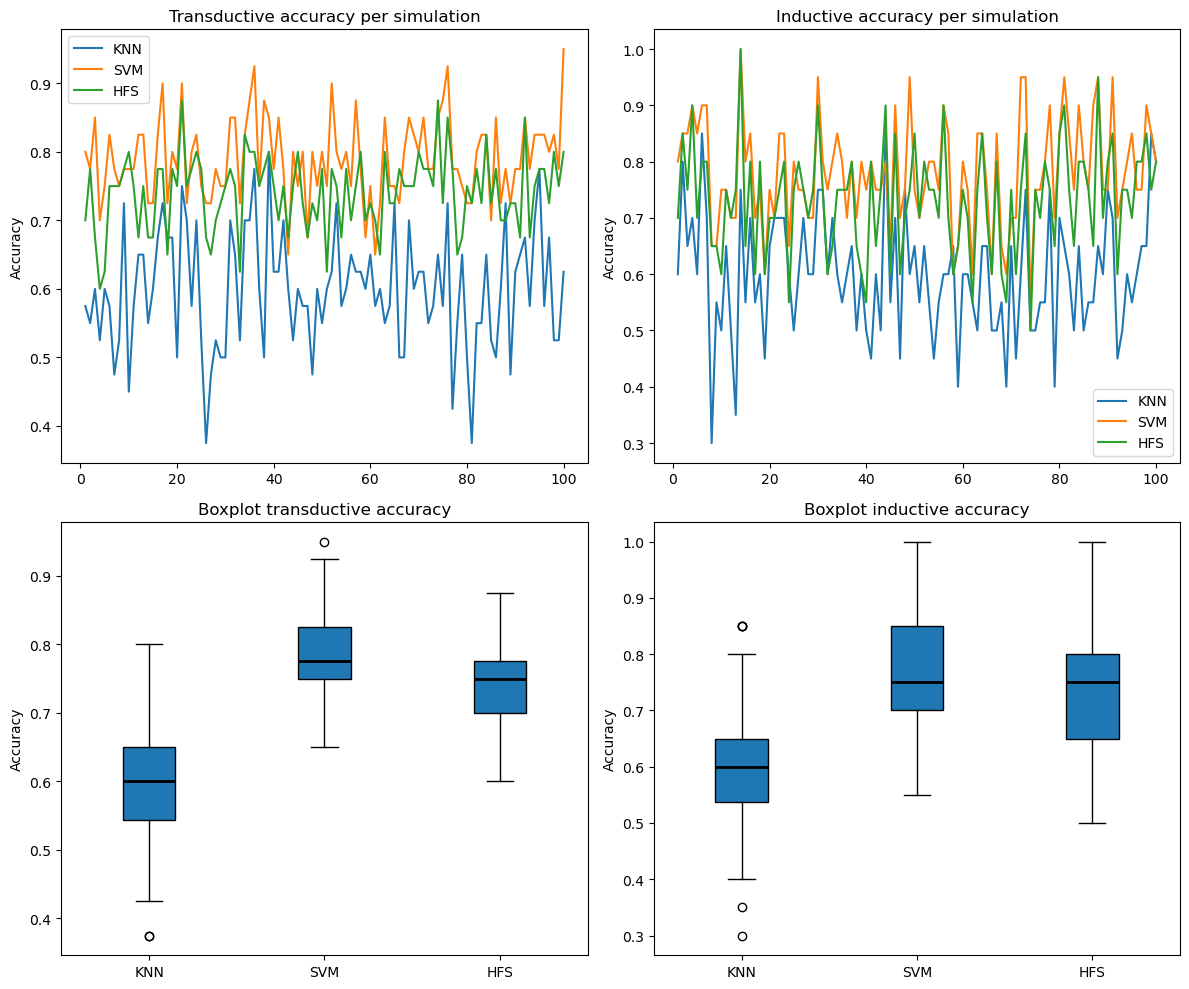

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

runs = np.arange(1, simus + 1)

ax = axes[0, 0]
ax.plot(runs, acc_knn_trans, label='KNN')
ax.plot(runs, acc_svm_trans, label='SVM')
ax.plot(runs, acc_hfs_trans, label='HFS')
ax.set_title('Transductive accuracy per simulation')
ax.set_ylabel('Accuracy')
ax.legend()

ax = axes[0, 1]
ax.plot(runs, acc_knn_ind, label='KNN')
ax.plot(runs, acc_svm_ind, label='SVM')
ax.plot(runs, acc_hfs_ind, label='HFS')
ax.set_title('Inductive accuracy per simulation')
ax.set_ylabel('Accuracy')
ax.legend()


ax = axes[1, 0]
bp = ax.boxplot([acc_knn_trans, acc_svm_trans, acc_hfs_trans], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
ax.set_xticklabels(['KNN', 'SVM', 'HFS'])
ax.set_title('Boxplot transductive accuracy')
ax.set_ylabel('Accuracy')

ax = axes[1, 1]
bp = ax.boxplot([acc_knn_ind, acc_svm_ind, acc_hfs_ind], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
ax.set_xticklabels(['KNN', 'SVM', 'HFS'])
ax.set_title('Boxplot inductive accuracy')
ax.set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

### Exact vs quantized

In the code below, I vary the maximum allowed number of centroids K ([40,50,60,70,80,100]) to see how the accuracy of the accuracy of the online algorithm evolves with K on the face images dataset of question 2. I also look at how the execution time vary with K. 

From the results below, we see that: 
- computational time increases with the number of centroids: on average, reducing the budget from K = 100 centroids to K = 40 centroids reduces the execution time by 6 (from 0.035 seconds to 0.006 seconds). 
- accuracy increases with the number of centroids: for K = 60, we have an average accuracy of 0.71, for K = 100 the accuracy is of 0.75. However benefit from the the increase in accuracy is marginal compared to the increase in computational time: we only increase accuracy by 0.02 points when switching from a budget of 40 centroids to a budget of 100 centroids while we multiply computational time by 7. 
- Hence, this example shows that it can be relevant to use quantization, because here, we have a very advantageous tradeoff between computational time and accuracy. 


In [72]:
import time

simus = 100
N_total = len(images)
budgets_K = [40,50,60,70,80,100]

results_acc = {k: [] for k in budgets_K}
results_time = {k: [] for k in budgets_K}

for run in range(simus):
    np.random.seed(SEED + run)
 
    shuffle_idx = np.random.permutation(N_total)
    X_shuffled = images[shuffle_idx]
    y_shuffled = labels[shuffle_idx]
  
    Y_masked = mask_labels(y_shuffled, l=4, per_class=True)
    l_idx = np.where(Y_masked > 0)[0]
    u_idx = np.where(Y_masked == 0)[0]
    
    X_labeled = X_shuffled[l_idx]
    Y_labeled = Y_masked[l_idx]
    label_names = [f"Class_{i}" for i in range(1, len(np.unique(labels))+1)]

    for K in budgets_K:
    
        model = IncrementalKCenters(X_labeled, Y_labeled.astype(int), label_names, max_num_centroids=K)
        
        for i in u_idx:
            model.online_ssl_update_centroids(X_shuffled[i])
            
        #start timer
        t_start = time.time()
        
        # compute f on the centroids
        if model.init:
            V_diag = np.ones(model.centroids.shape[0])
        else:
            V_diag = model.V
        V = np.diag(V_diag)
        W_tilde = build_similarity_graph(model.centroids, var=params_face_rec['var'], eps=0, k=params_face_rec['k'])
        W_g = V @ W_tilde @ V
        L = build_laplacian(W_g, params_face_rec['laplacian_normalization'])
        Q = L + params_face_rec['laplacian_regularization'] * np.eye(L.shape[0])
        
        # HFS on the graph with K nodes
        pred_centroids, _ = compute_hfs(Q, model.Y, soft=False, **params_face_rec)
        
        t_end = time.time()
        

        #compute transductive accuracy
        dist_to_centroids = distance.cdist(X_shuffled[u_idx], model.centroids)
        nearest_centroid_idx = np.argmin(dist_to_centroids, axis=1)
        pred_u = pred_centroids[nearest_centroid_idx]
        acc = accuracy_score(y_shuffled[u_idx], pred_u)

        results_acc[K].append(acc)
        results_time[K].append(t_end - t_start)


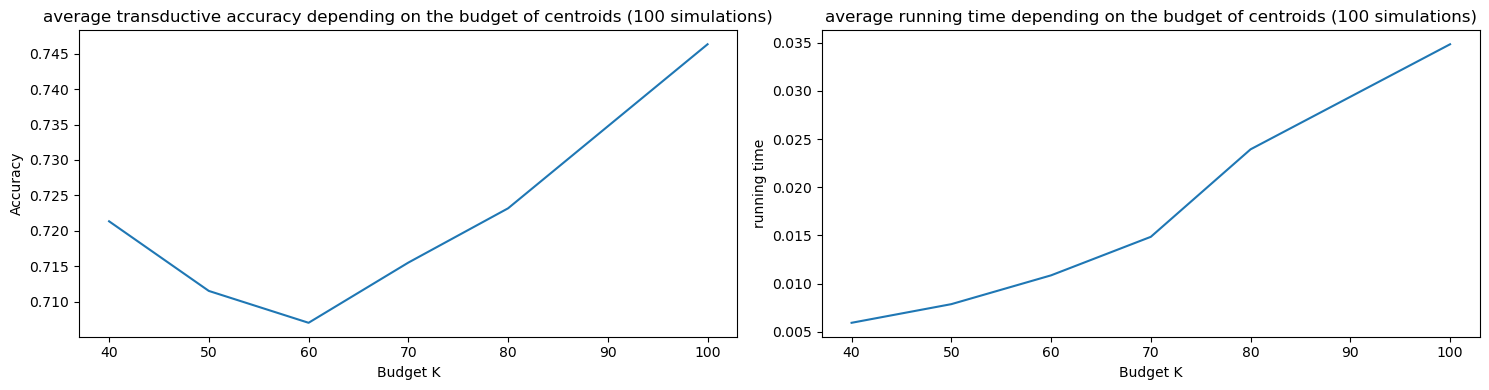

In [74]:
K_values = list(budgets_K)
mean_acc = [np.mean(results_acc[k]) for k in K_values]
mean_time = [np.mean(results_time[k]) for k in K_values]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))


ax1.plot(K_values, mean_acc)
ax1.set_xlabel('Budget K')
ax1.set_ylabel('Accuracy')
ax1.set_title('average transductive accuracy depending on the budget of centroids (100 simulations)')


ax2.plot(K_values, mean_time)
ax2.set_xlabel('Budget K')
ax2.set_ylabel('running time')
ax2.set_title('average running time depending on the budget of centroids (100 simulations)')

plt.tight_layout()
plt.show()